# 04 - Statistical Tests

## Price Intelligence Platform

Ce notebook vérifie statistiquement les observations détectées dans l'analyse exploratoire.

**Objectifs :**

- tester si les prix diffèrent significativement entre plateformes,
- tester si les prix diffèrent significativement entre catégories,
- comparer les plateformes deux à deux,
- analyser la relation entre prix, notes clients et remises,
- construire une régression explicative du prix,
- sauvegarder les résultats statistiques pour le rapport final.

## 1. Hypothèses statistiques

Nous allons tester les hypothèses suivantes :

### H1 - Différence de prix entre plateformes

- **H0** : les distributions de prix sont similaires entre plateformes.
- **H1** : au moins une plateforme présente des prix significativement différents.

### H2 - Différence de prix entre catégories

- **H0** : les distributions de prix sont similaires entre catégories.
- **H1** : au moins une catégorie présente des prix significativement différents.

### H3 - Relation entre note client et prix

- **H0** : il n'existe pas de relation monotone entre note client et prix.
- **H1** : il existe une relation monotone entre note client et prix.

Seuil de significativité utilisé : **alpha = 0.05**.

## 2. Imports et configuration

In [ ]:
from pathlib import Path
from itertools import combinations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf



def find_analytics_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    candidates += [candidate / "analytics" for candidate in candidates]
    for candidate in candidates:
        if (candidate / "price_analysis.py").exists() and (candidate / "notebooks").exists():
            return candidate.resolve()
    raise FileNotFoundError("Impossible de trouver le dossier analytics. Ouvre le notebook depuis le repo price-intelligence ou analytics/notebooks.")

DATA_ANALYSIS_DIR = find_analytics_root()
PROJECT_ROOT = DATA_ANALYSIS_DIR.parent

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ALPHA = 0.05

print("Dossier de travail Data Analysis :", DATA_ANALYSIS_DIR)
print("Seuil de significativité alpha :", ALPHA)

## 3. Configuration de l'auto-sauvegarde

In [2]:
OUTPUTS_DIR = DATA_ANALYSIS_DIR / "outputs"
OUTPUT_TABLES = OUTPUTS_DIR / "tables"
OUTPUT_FIGURES = OUTPUTS_DIR / "figures"
OUTPUT_CLEANED = OUTPUTS_DIR / "cleaned_data"

OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

AUTO_SAVE = True

print("Auto-sauvegarde activée :", AUTO_SAVE)
print("Dossier des tableaux :", OUTPUT_TABLES)
print("Dossier des graphiques :", OUTPUT_FIGURES)

Auto-sauvegarde activée : True
Dossier des tableaux : C:\Users\Admin\Desktop\data-analysis\outputs\tables
Dossier des graphiques : C:\Users\Admin\Desktop\data-analysis\outputs\figures


## 4. Chargement du dataset nettoyé

In [3]:

EXPECTED_MIN_CLEAN_ROWS = 5000
EXPECTED_STORE = "sport-direct"
EXPECTED_MIN_SCRAPE_DATE = pd.Timestamp("2026-05-19")

def assert_current_clean_dataset(df, path):
    stores = set(df.get("store", pd.Series(dtype="object")).dropna().astype(str).str.lower())
    scraped_at = pd.to_datetime(df.get("scraped_at", pd.Series(dtype="object")), errors="coerce")
    max_scrape = scraped_at.max()

    if len(df) < EXPECTED_MIN_CLEAN_ROWS:
        raise ValueError(
            f"Dataset nettoye trop petit: {len(df)} lignes seulement dans {path}. "
            "Relance 02_data_cleaning.ipynb apres BigQuery live."
        )
    if EXPECTED_STORE not in stores:
        raise ValueError(
            f"Dataset nettoye stale: store {EXPECTED_STORE} absent dans {path}. "
            "Relance 02_data_cleaning.ipynb."
        )
    if pd.isna(max_scrape) or max_scrape < EXPECTED_MIN_SCRAPE_DATE:
        raise ValueError(
            f"Dataset nettoye stale: derniere date scrape = {max_scrape}. "
            "Relance 01 puis 02 avec BigQuery live."
        )


In [4]:
clean_path = OUTPUT_CLEANED / "02_clean_prices_no_outliers.csv"

if not clean_path.exists():
    raise FileNotFoundError(f"Dataset nettoye introuvable : {clean_path}. Execute d'abord 02_data_cleaning.ipynb.")

df = pd.read_csv(clean_path)
assert_current_clean_dataset(df, clean_path)
df["scraped_at"] = pd.to_datetime(df["scraped_at"], errors="coerce")

print("Dataset charge :", clean_path)
print("Nombre de lignes :", len(df))
print("Plateformes :", sorted(df["store"].dropna().astype(str).str.lower().unique()))
print("Categories :", sorted(df["category"].dropna().astype(str).str.lower().unique()))
print("Periode scrape :", df["scraped_at"].min(), "->", df["scraped_at"].max())

df.head()


Dataset charge : C:\Users\Admin\Desktop\data-analysis\outputs\cleaned_data\02_clean_prices_no_outliers.csv
Nombre de lignes : 6580
Plateformes : ['ebay', 'jumia', 'sport-direct']
Categories : ['basketball', 'combat-sports', 'football', 'gym', 'racket-sports', 'unknown', 'volleyball']
Periode scrape : 2026-05-15 16:51:15.694877 -> 2026-05-20 13:09:12.077671


,store,category,name,price,price_before_discount,discount,stars,availability,scraped_at,scraped_date,is_price_outlier
0,ebay,unknown,Nutricost Whey Protein Concentrate (Chocolate)...,342.0600,NaN,NaN,0.0000,in stock,2026-05-20 13:05:00.571474,2026-05-20,False
1,ebay,unknown,Shin Guards pads Instep MMA Muay Thai Kick Box...,118.3100,NaN,NaN,0.0000,in stock,2026-05-20 13:07:19.570569,2026-05-20,False
2,ebay,unknown,Nutricost Grass-Fed Whey Protein Concentrate (...,786.0700,NaN,NaN,0.0000,in stock,2026-05-20 13:05:00.561012,2026-05-20,False
3,ebay,unknown,Knee Sleeve Compression Brace Support For Spor...,83.1600,NaN,NaN,0.0000,in stock,2026-05-20 13:01:45.805711,2026-05-20,False
4,ebay,unknown,Zinc Max Strength 100mg 180 Tablets Vegan Supp...,98.9700,NaN,NaN,0.0000,in stock,2026-05-20 13:04:31.198784,2026-05-20,False


## 5. Préparation des groupes de test

In [5]:
store_groups = {
    store: group["price"].dropna().values
    for store, group in df.groupby("store")
    if group["price"].dropna().shape[0] >= 2
}

category_groups = {
    category: group["price"].dropna().values
    for category, group in df.groupby("category")
    if group["price"].dropna().shape[0] >= 2
}

print("Groupes plateformes :", {k: len(v) for k, v in store_groups.items()})
print("Groupes catégories :", {k: len(v) for k, v in category_groups.items()})

Groupes plateformes : {'ebay': 4372, 'jumia': 1062, 'sport-direct': 1146}
Groupes catégories : {'basketball': 521, 'combat-sports': 705, 'football': 689, 'gym': 559, 'racket-sports': 250, 'unknown': 3586, 'volleyball': 270}


## 6. Test de normalité

Le test de Shapiro-Wilk vérifie si une distribution suit approximativement une loi normale. Pour éviter les limites du test avec de grands échantillons, on utilise un échantillon maximum de 500 valeurs par groupe.

In [6]:
def shapiro_by_group(dataframe, group_col, value_col="price", max_sample=500):
    results = []
    for group_name, group in dataframe.groupby(group_col):
        values = group[value_col].dropna()
        if len(values) < 3:
            continue
        sample = values.sample(min(len(values), max_sample), random_state=42)
        statistic, p_value = stats.shapiro(sample)
        results.append({
            "groupe": group_name,
            "n": len(values),
            "statistic": statistic,
            "p_value": p_value,
            "normalite_rejetee": p_value < ALPHA
        })
    return pd.DataFrame(results)

normality_store = shapiro_by_group(df, "store")
normality_category = shapiro_by_group(df, "category")

print("Normalité par plateforme :")
display(normality_store)

print("Normalité par catégorie :")
display(normality_category)

Normalité par plateforme :


,groupe,n,statistic,p_value,normalite_rejetee
0,ebay,4372,0.9057,0.0000,True
1,jumia,1062,0.7988,0.0000,True
2,sport-direct,1146,0.8627,0.0000,True


Normalité par catégorie :


,groupe,n,statistic,p_value,normalite_rejetee
0,basketball,521,0.8700,0.0000,True
1,combat-sports,705,0.8149,0.0000,True
2,football,689,0.9095,0.0000,True
3,gym,559,0.8723,0.0000,True
4,racket-sports,250,0.8449,0.0000,True
5,unknown,3586,0.8533,0.0000,True
6,volleyball,270,0.9215,0.0000,True


## 7. Test d'homogénéité des variances

Le test de Levene vérifie si les groupes ont des variances similaires. Si les variances ne sont pas homogènes, les tests non paramétriques deviennent plus appropriés.

In [7]:
levene_store_stat, levene_store_p = stats.levene(*store_groups.values(), center="median")
levene_category_stat, levene_category_p = stats.levene(*category_groups.values(), center="median")

levene_results = pd.DataFrame([
    {"test": "Levene - plateformes", "statistic": levene_store_stat, "p_value": levene_store_p, "variances_homogenes": levene_store_p >= ALPHA},
    {"test": "Levene - catégories", "statistic": levene_category_stat, "p_value": levene_category_p, "variances_homogenes": levene_category_p >= ALPHA},
])

levene_results

,test,statistic,p_value,variances_homogenes
0,Levene - plateformes,116.0240,0.0000,False
1,Levene - catégories,14.9930,0.0000,False


## 8. Différence de prix entre plateformes

In [8]:
anova_store_stat, anova_store_p = stats.f_oneway(*store_groups.values())
kruskal_store_stat, kruskal_store_p = stats.kruskal(*store_groups.values())

store_test_results = pd.DataFrame([
    {
        "hypothese": "Différence de prix entre plateformes",
        "test": "ANOVA",
        "statistic": anova_store_stat,
        "p_value": anova_store_p,
        "significatif": anova_store_p < ALPHA,
        "interpretation": "Différence significative" if anova_store_p < ALPHA else "Différence non significative",
    },
    {
        "hypothese": "Différence de prix entre plateformes",
        "test": "Kruskal-Wallis",
        "statistic": kruskal_store_stat,
        "p_value": kruskal_store_p,
        "significatif": kruskal_store_p < ALPHA,
        "interpretation": "Différence significative" if kruskal_store_p < ALPHA else "Différence non significative",
    },
])

store_test_results

,hypothese,test,statistic,p_value,significatif,interpretation
0,Différence de prix entre plateformes,ANOVA,166.3688,0.0000,True,Différence significative
1,Différence de prix entre plateformes,Kruskal-Wallis,390.2935,0.0000,True,Différence significative


## 9. Différence de prix entre catégories

In [9]:
anova_category_stat, anova_category_p = stats.f_oneway(*category_groups.values())
kruskal_category_stat, kruskal_category_p = stats.kruskal(*category_groups.values())

category_test_results = pd.DataFrame([
    {
        "hypothese": "Différence de prix entre catégories",
        "test": "ANOVA",
        "statistic": anova_category_stat,
        "p_value": anova_category_p,
        "significatif": anova_category_p < ALPHA,
        "interpretation": "Différence significative" if anova_category_p < ALPHA else "Différence non significative",
    },
    {
        "hypothese": "Différence de prix entre catégories",
        "test": "Kruskal-Wallis",
        "statistic": kruskal_category_stat,
        "p_value": kruskal_category_p,
        "significatif": kruskal_category_p < ALPHA,
        "interpretation": "Différence significative" if kruskal_category_p < ALPHA else "Différence non significative",
    },
])

category_test_results

,hypothese,test,statistic,p_value,significatif,interpretation
0,Différence de prix entre catégories,ANOVA,18.9661,0.0000,True,Différence significative
1,Différence de prix entre catégories,Kruskal-Wallis,112.8757,0.0000,True,Différence significative


## 10. Comparaisons deux à deux entre plateformes

On utilise Mann-Whitney U, adapté aux distributions non normales. La p-value est corrigée avec Bonferroni pour limiter les faux positifs.

In [10]:
pairwise_store_results = []
pairs = list(combinations(store_groups.keys(), 2))

for group_a, group_b in pairs:
    values_a = store_groups[group_a]
    values_b = store_groups[group_b]
    statistic, p_value = stats.mannwhitneyu(values_a, values_b, alternative="two-sided")
    corrected_p = min(p_value * len(pairs), 1.0)
    pairwise_store_results.append({
        "groupe_a": group_a,
        "groupe_b": group_b,
        "median_a": np.median(values_a),
        "median_b": np.median(values_b),
        "test": "Mann-Whitney U",
        "statistic": statistic,
        "p_value": p_value,
        "p_value_bonferroni": corrected_p,
        "significatif": corrected_p < ALPHA,
    })

pairwise_store_results = pd.DataFrame(pairwise_store_results)
pairwise_store_results

,groupe_a,groupe_b,median_a,median_b,test,statistic,p_value,p_value_bonferroni,significatif
0,ebay,jumia,333.0000,179.9900,Mann-Whitney U,"3,211,973.0000",0.0000,0.0000,True
1,ebay,sport-direct,333.0000,300.0000,Mann-Whitney U,"2,620,417.5000",0.0163,0.0490,True
2,jumia,sport-direct,179.9900,300.0000,Mann-Whitney U,"385,723.0000",0.0000,0.0000,True


## 11. Comparaisons deux à deux entre catégories

In [11]:
pairwise_category_results = []
category_pairs = list(combinations(category_groups.keys(), 2))

for group_a, group_b in category_pairs:
    values_a = category_groups[group_a]
    values_b = category_groups[group_b]
    statistic, p_value = stats.mannwhitneyu(values_a, values_b, alternative="two-sided")
    corrected_p = min(p_value * len(category_pairs), 1.0)
    pairwise_category_results.append({
        "groupe_a": group_a,
        "groupe_b": group_b,
        "median_a": np.median(values_a),
        "median_b": np.median(values_b),
        "test": "Mann-Whitney U",
        "statistic": statistic,
        "p_value": p_value,
        "p_value_bonferroni": corrected_p,
        "significatif": corrected_p < ALPHA,
    })

pairwise_category_results = pd.DataFrame(pairwise_category_results).sort_values("p_value_bonferroni")
pairwise_category_results.head(20)

,groupe_a,groupe_b,median_a,median_b,test,statistic,p_value,p_value_bonferroni,significatif
6,combat-sports,football,222.0000,369.9100,Mann-Whitney U,"174,209.5000",0.0000,0.0000,True
11,football,gym,369.9100,296.0000,Mann-Whitney U,"238,438.0000",0.0000,0.0000,True
10,combat-sports,volleyball,222.0000,369.9550,Mann-Whitney U,"69,504.5000",0.0000,0.0000,True
13,football,unknown,369.9100,296.9700,Mann-Whitney U,"1,420,244.0000",0.0000,0.0000,True
9,combat-sports,unknown,222.0000,296.9700,Mann-Whitney U,"1,092,357.5000",0.0000,0.0000,True
17,gym,volleyball,296.0000,369.9550,Mann-Whitney U,"57,755.5000",0.0000,0.0000,True
1,basketball,football,283.4200,369.9100,Mann-Whitney U,"150,892.5000",0.0000,0.0000,True
20,unknown,volleyball,296.9700,369.9550,Mann-Whitney U,"414,301.5000",0.0001,0.0016,True
0,basketball,combat-sports,283.4200,222.0000,Mann-Whitney U,"207,301.0000",0.0001,0.0024,True
8,combat-sports,racket-sports,222.0000,298.9600,Mann-Whitney U,"74,754.0000",0.0004,0.0075,True


## 12. Corrélation entre prix, remises et notes clients

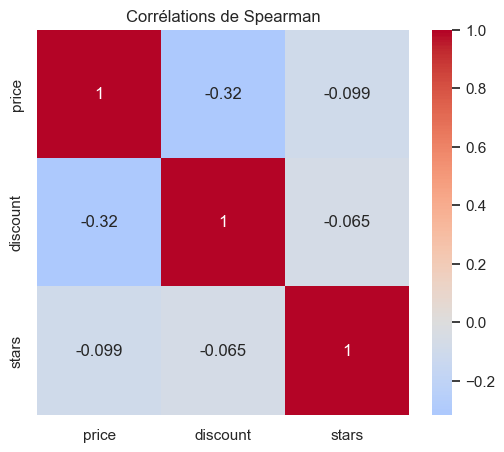

,price,discount,stars
price,1.0000,-0.3169,-0.0985
discount,-0.3169,1.0000,-0.0653
stars,-0.0985,-0.0653,1.0000


In [12]:
correlation_df = df[["price", "discount", "stars"]].dropna(how="all").copy()

correlation_matrix = correlation_df.corr(method="spearman")

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Corrélations de Spearman")

if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "04_correlation_spearman.png", dpi=150, bbox_inches="tight")

plt.show()
correlation_matrix

In [13]:
corr_tests = []

for variable in ["discount", "stars"]:
    subset = df[["price", variable]].dropna()
    if len(subset) >= 3:
        statistic, p_value = stats.spearmanr(subset["price"], subset[variable])
        corr_tests.append({
            "variables": f"price vs {variable}",
            "test": "Spearman",
            "n": len(subset),
            "correlation": statistic,
            "p_value": p_value,
            "significatif": p_value < ALPHA,
        })

corr_tests = pd.DataFrame(corr_tests)
corr_tests

,variables,test,n,correlation,p_value,significatif
0,price vs discount,Spearman,1510,-0.3169,0.0000,True
1,price vs stars,Spearman,6580,-0.0985,0.0000,True


## 13. Régression explicative du prix

On modélise le logarithme du prix pour réduire l'effet de l'asymétrie de la distribution. Les variables explicatives sont la plateforme, la catégorie, la note client et la remise.

In [14]:
regression_df = df[["price", "store", "category", "stars", "discount"]].copy()
regression_df = regression_df.dropna(subset=["price", "store", "category"])

# Pour éviter de supprimer trop de lignes, les notes/remises manquantes sont imputées à la médiane.
regression_df["stars"] = regression_df["stars"].fillna(regression_df["stars"].median())
regression_df["discount"] = regression_df["discount"].fillna(0)
regression_df["log_price"] = np.log1p(regression_df["price"])

model = smf.ols("log_price ~ C(store) + C(category) + stars + discount", data=regression_df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     64.51
Date:                Wed, 20 May 2026   Prob (F-statistic):          7.56e-126
Time:                        16:24:38   Log-Likelihood:                -8533.7
No. Observations:                6580   AIC:                         1.709e+04
Df Residuals:                    6569   BIC:                         1.716e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [15]:
regression_results = pd.DataFrame({
    "variable": model.params.index,
    "coefficient": model.params.values,
    "p_value": model.pvalues.values,
    "significatif": model.pvalues.values < ALPHA,
})

regression_summary = pd.DataFrame([
    {"metric": "r_squared", "value": model.rsquared},
    {"metric": "adj_r_squared", "value": model.rsquared_adj},
    {"metric": "f_pvalue", "value": model.f_pvalue},
    {"metric": "n_observations", "value": model.nobs},
])

display(regression_summary)
regression_results

,metric,value
0,r_squared,0.0894
1,adj_r_squared,0.0880
2,f_pvalue,0.0000
3,n_observations,"6,580.0000"


,variable,coefficient,p_value,significatif
0,Intercept,5.7511,0.0000,True
1,C(store)[T.jumia],-0.4086,0.0000,True
2,C(store)[T.sport-direct],0.1589,0.0000,True
3,C(category)[T.combat-sports],-0.2161,0.0000,True
4,C(category)[T.football],0.1977,0.0001,True
5,C(category)[T.gym],-0.1116,0.0410,True
6,C(category)[T.racket-sports],0.0269,0.6933,False
7,C(category)[T.unknown],-0.0239,0.5671,False
8,C(category)[T.volleyball],0.1890,0.0046,True
9,stars,-0.0033,0.7229,False


## 14. Visualisation des différences significatives

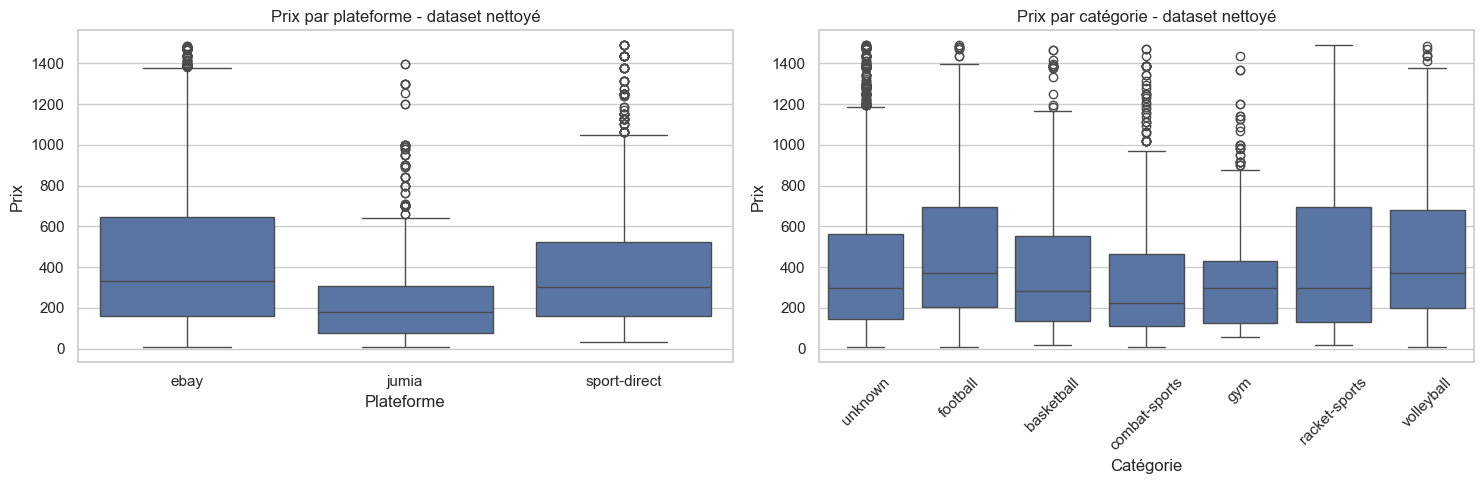

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x="store", y="price", ax=axes[0])
axes[0].set_title("Prix par plateforme - dataset nettoyé")
axes[0].set_xlabel("Plateforme")
axes[0].set_ylabel("Prix")

sns.boxplot(data=df, x="category", y="price", ax=axes[1])
axes[1].set_title("Prix par catégorie - dataset nettoyé")
axes[1].set_xlabel("Catégorie")
axes[1].set_ylabel("Prix")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "04_boxplots_tests_statistiques.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Synthèse automatique des résultats

In [17]:
statistical_insights = []

if kruskal_store_p < ALPHA:
    statistical_insights.append("Les prix diffèrent significativement entre plateformes selon le test de Kruskal-Wallis.")
else:
    statistical_insights.append("Le test de Kruskal-Wallis ne détecte pas de différence significative entre plateformes.")

if kruskal_category_p < ALPHA:
    statistical_insights.append("Les prix diffèrent significativement entre catégories selon le test de Kruskal-Wallis.")
else:
    statistical_insights.append("Le test de Kruskal-Wallis ne détecte pas de différence significative entre catégories.")

significant_pairs_store = pairwise_store_results[pairwise_store_results["significatif"]]
statistical_insights.append(f"Nombre de comparaisons significatives entre plateformes après correction Bonferroni : {len(significant_pairs_store)}.")

for _, row in corr_tests.iterrows():
    if row["significatif"]:
        statistical_insights.append(f"La relation {row['variables']} est statistiquement significative, avec une corrélation de {row['correlation']:.3f}.")
    else:
        statistical_insights.append(f"La relation {row['variables']} n'est pas statistiquement significative.")

statistical_insights_df = pd.DataFrame({"insight": statistical_insights})

for insight in statistical_insights:
    print("-", insight)

statistical_insights_df

- Les prix diffèrent significativement entre plateformes selon le test de Kruskal-Wallis.
- Les prix diffèrent significativement entre catégories selon le test de Kruskal-Wallis.
- Nombre de comparaisons significatives entre plateformes après correction Bonferroni : 3.
- La relation price vs discount est statistiquement significative, avec une corrélation de -0.317.
- La relation price vs stars est statistiquement significative, avec une corrélation de -0.099.


,insight
0,Les prix diffèrent significativement entre pla...
1,Les prix diffèrent significativement entre cat...
2,Nombre de comparaisons significatives entre pl...
3,La relation price vs discount est statistiquem...
4,La relation price vs stars est statistiquement...


## 16. Sauvegarde automatique des résultats statistiques

In [18]:
all_test_results = pd.concat([store_test_results, category_test_results], ignore_index=True)

if AUTO_SAVE:
    normality_store.to_csv(OUTPUT_TABLES / "04_normality_by_store.csv", index=False, encoding="utf-8-sig")
    normality_category.to_csv(OUTPUT_TABLES / "04_normality_by_category.csv", index=False, encoding="utf-8-sig")
    levene_results.to_csv(OUTPUT_TABLES / "04_levene_results.csv", index=False, encoding="utf-8-sig")
    all_test_results.to_csv(OUTPUT_TABLES / "04_main_statistical_tests.csv", index=False, encoding="utf-8-sig")
    pairwise_store_results.to_csv(OUTPUT_TABLES / "04_pairwise_store_tests.csv", index=False, encoding="utf-8-sig")
    pairwise_category_results.to_csv(OUTPUT_TABLES / "04_pairwise_category_tests.csv", index=False, encoding="utf-8-sig")
    correlation_matrix.to_csv(OUTPUT_TABLES / "04_spearman_correlation_matrix.csv", encoding="utf-8-sig")
    corr_tests.to_csv(OUTPUT_TABLES / "04_correlation_tests.csv", index=False, encoding="utf-8-sig")
    regression_summary.to_csv(OUTPUT_TABLES / "04_regression_summary.csv", index=False, encoding="utf-8-sig")
    regression_results.to_csv(OUTPUT_TABLES / "04_regression_coefficients.csv", index=False, encoding="utf-8-sig")
    statistical_insights_df.to_csv(OUTPUT_TABLES / "04_statistical_insights.csv", index=False, encoding="utf-8-sig")

    print("Sauvegarde des tests statistiques terminée.")
    print("Tableaux sauvegardés dans :", OUTPUT_TABLES)
    print("Graphiques sauvegardés dans :", OUTPUT_FIGURES)
else:
    print("Auto-sauvegarde désactivée.")

Sauvegarde des tests statistiques terminée.
Tableaux sauvegardés dans : C:\Users\Admin\Desktop\data-analysis\outputs\tables
Graphiques sauvegardés dans : C:\Users\Admin\Desktop\data-analysis\outputs\figures


## 17. Conclusion - Statistical Tests

À compléter après exécution du notebook :

- Les distributions des prix sont-elles normales ?
- Les variances sont-elles homogènes ?
- Les prix diffèrent-ils significativement entre plateformes ?
- Les prix diffèrent-ils significativement entre catégories ?
- Quelles comparaisons deux à deux sont significatives ?
- Existe-t-il une relation significative entre prix et note client ?
- Les variables plateforme/catégorie expliquent-elles une partie du prix dans la régression ?

**Prochaine phase :** `05_final_insights.ipynb`, pour transformer les résultats statistiques en conclusions business et recommandations finales.


## 18. Intervalles de confiance à 95%

Cette section ajoute des intervalles de confiance bootstrap pour les prix médians par plateforme et par catégorie. Cela complète les p-values avec une estimation de l'incertitude autour des KPIs.


In [19]:

def bootstrap_median_ci(values, n_boot=2000, ci=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    values = np.asarray(pd.Series(values).dropna())
    if len(values) < 2:
        return pd.Series({"median": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": len(values)})
    boot = [np.median(rng.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    alpha = 1 - ci
    return pd.Series({
        "n": len(values),
        "median": np.median(values),
        "ci_low": np.quantile(boot, alpha / 2),
        "ci_high": np.quantile(boot, 1 - alpha / 2),
    })

ci_median_store = df.groupby("store")["price"].apply(bootstrap_median_ci).unstack().reset_index().rename(columns={"store": "plateforme"})
ci_median_category = df.groupby("category")["price"].apply(bootstrap_median_ci).unstack().reset_index().rename(columns={"category": "categorie"})

display(ci_median_store)
display(ci_median_category)


,plateforme,n,median,ci_low,ci_high
0,ebay,"4,372.0000",333.0000,323.6600,344.3800
1,jumia,"1,062.0000",179.9900,167.3250,197.0125
2,sport-direct,"1,146.0000",300.0000,275.0000,312.5000


,categorie,n,median,ci_low,ci_high
0,basketball,521.0000,283.4200,250.9500,323.6600
1,combat-sports,705.0000,222.0000,199.0000,240.4100
2,football,689.0000,369.9100,333.0000,416.1600
3,gym,559.0000,296.0000,265.9615,317.7400
4,racket-sports,250.0000,298.9600,250.0000,337.5000
5,unknown,"3,586.0000",296.9700,279.0000,311.8200
6,volleyball,270.0000,369.9550,331.0026,459.6800



## 19. Taille d'effet

Les p-values indiquent si un résultat est statistiquement significatif. La **taille d'effet** indique si la différence est importante en pratique.


In [20]:

def cohens_d(x, y):
    x = np.asarray(pd.Series(x).dropna())
    y = np.asarray(pd.Series(y).dropna())
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2))
    if pooled_std == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled_std

pairwise_store_effects = []
for group_a, group_b in combinations(store_groups.keys(), 2):
    d = cohens_d(store_groups[group_a], store_groups[group_b])
    pairwise_store_effects.append({
        "groupe_a": group_a,
        "groupe_b": group_b,
        "cohens_d": d,
        "absolute_effect": abs(d),
        "interpretation": "faible" if abs(d) < 0.2 else "moyen" if abs(d) < 0.8 else "fort",
    })

pairwise_store_effects = pd.DataFrame(pairwise_store_effects)
pairwise_store_effects


,groupe_a,groupe_b,cohens_d,absolute_effect,interpretation
0,ebay,jumia,0.6211,0.6211,moyen
1,ebay,sport-direct,0.1197,0.1197,faible
2,jumia,sport-direct,-0.5914,0.5914,moyen


In [21]:

def eta_squared_from_anova(groups):
    all_values = np.concatenate([np.asarray(values) for values in groups])
    grand_mean = np.mean(all_values)
    ss_between = sum(len(values) * (np.mean(values) - grand_mean) ** 2 for values in groups)
    ss_total = sum((value - grand_mean) ** 2 for value in all_values)
    return ss_between / ss_total if ss_total > 0 else np.nan

def epsilon_squared_kruskal(h_stat, n, k):
    return (h_stat - k + 1) / (n - k) if n > k else np.nan

store_eta_sq = eta_squared_from_anova(list(store_groups.values()))
category_eta_sq = eta_squared_from_anova(list(category_groups.values()))
store_epsilon_sq = epsilon_squared_kruskal(kruskal_store_stat, len(df), len(store_groups))
category_epsilon_sq = epsilon_squared_kruskal(kruskal_category_stat, len(df), len(category_groups))

effect_size_summary = pd.DataFrame([
    {"comparison": "plateformes", "metric": "eta_squared_anova", "value": store_eta_sq},
    {"comparison": "catégories", "metric": "eta_squared_anova", "value": category_eta_sq},
    {"comparison": "plateformes", "metric": "epsilon_squared_kruskal", "value": store_epsilon_sq},
    {"comparison": "catégories", "metric": "epsilon_squared_kruskal", "value": category_epsilon_sq},
])

effect_size_summary


,comparison,metric,value
0,plateformes,eta_squared_anova,0.0482
1,catégories,eta_squared_anova,0.0170
2,plateformes,epsilon_squared_kruskal,0.0590
3,catégories,epsilon_squared_kruskal,0.0163



## 20. Analyse de puissance statistique

Cette section complète l'exigence du PDF sur la **power analysis**. Elle estime si l'échantillon est suffisant pour détecter les effets observés.


In [22]:

from statsmodels.stats.power import FTestAnovaPower, TTestIndPower

power_rows = []

for comparison, eta_sq, groups_count in [
    ("plateformes", store_eta_sq, len(store_groups)),
    ("catégories", category_eta_sq, len(category_groups)),
]:
    if pd.notna(eta_sq) and eta_sq > 0 and eta_sq < 1:
        effect_f = np.sqrt(eta_sq / (1 - eta_sq))
        power = FTestAnovaPower().power(effect_size=effect_f, k_groups=groups_count, nobs=len(df), alpha=ALPHA)
        power_rows.append({
            "comparison": comparison,
            "test_family": "ANOVA",
            "effect_size": effect_f,
            "nobs": len(df),
            "groups": groups_count,
            "alpha": ALPHA,
            "power": power,
            "interpretation": "puissance suffisante" if power >= 0.8 else "puissance insuffisante",
        })

for _, row in pairwise_store_effects.iterrows():
    n_a = len(store_groups[row["groupe_a"]])
    n_b = len(store_groups[row["groupe_b"]])
    ratio = n_b / n_a if n_a else 1
    if pd.notna(row["absolute_effect"]) and row["absolute_effect"] > 0:
        power = TTestIndPower().power(effect_size=row["absolute_effect"], nobs1=n_a, alpha=ALPHA, ratio=ratio, alternative="two-sided")
        power_rows.append({
            "comparison": f"{row['groupe_a']} vs {row['groupe_b']}",
            "test_family": "pairwise approximation",
            "effect_size": row["absolute_effect"],
            "nobs": n_a + n_b,
            "groups": 2,
            "alpha": ALPHA,
            "power": power,
            "interpretation": "puissance suffisante" if power >= 0.8 else "puissance insuffisante",
        })

power_analysis_results = pd.DataFrame(power_rows)
power_analysis_results


,comparison,test_family,effect_size,nobs,groups,alpha,power,interpretation
0,plateformes,ANOVA,0.2249,6580,3,0.0500,1.0000,puissance suffisante
1,catégories,ANOVA,0.1316,6580,7,0.0500,1.0000,puissance suffisante
2,ebay vs jumia,pairwise approximation,0.6211,5434,2,0.0500,1.0000,puissance suffisante
3,ebay vs sport-direct,pairwise approximation,0.1197,5518,2,0.0500,0.9503,puissance suffisante
4,jumia vs sport-direct,pairwise approximation,0.5914,2208,2,0.0500,1.0000,puissance suffisante



## 21. Régression avec variable temporelle

Le PDF mentionne `price ~ rating + reviews + time`. La variable `reviews` n'est pas disponible dans les données scrapées. On ajoute donc une variable temporelle `days_since_start` calculée depuis `scraped_at`.


In [23]:

time_regression_df = df[["price", "store", "category", "stars", "discount", "scraped_at"]].copy()
time_regression_df["scraped_at"] = pd.to_datetime(time_regression_df["scraped_at"], errors="coerce")
time_regression_df = time_regression_df.dropna(subset=["price", "store", "category", "scraped_at"])
time_regression_df["stars"] = time_regression_df["stars"].fillna(time_regression_df["stars"].median())
time_regression_df["discount"] = time_regression_df["discount"].fillna(0)
time_regression_df["days_since_start"] = (time_regression_df["scraped_at"] - time_regression_df["scraped_at"].min()).dt.total_seconds() / 86400
ntime_dates = time_regression_df["scraped_at"].dt.date.nunique()

if ntime_dates >= 2:
    time_regression_df["log_price"] = np.log1p(time_regression_df["price"])
    model_time = smf.ols("log_price ~ C(store) + C(category) + stars + discount + days_since_start", data=time_regression_df).fit()
    print(model_time.summary())
else:
    model_time = None
    print("Régression temporelle non interprétable : une seule date distincte ou pas assez de variation temporelle.")
    print("Nombre de dates distinctes :", ntime_dates)


                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     58.81
Date:                Wed, 20 May 2026   Prob (F-statistic):          2.59e-125
Time:                        16:24:45   Log-Likelihood:                -8532.8
No. Observations:                6580   AIC:                         1.709e+04
Df Residuals:                    6568   BIC:                         1.717e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [24]:

regression_confidence_intervals = pd.DataFrame({
    "variable": model.params.index,
    "coefficient": model.params.values,
    "ci_low_95": model.conf_int()[0].values,
    "ci_high_95": model.conf_int()[1].values,
    "p_value": model.pvalues.values,
    "significatif": model.pvalues.values < ALPHA,
})

if model_time is not None:
    regression_time_results = pd.DataFrame({
        "variable": model_time.params.index,
        "coefficient": model_time.params.values,
        "ci_low_95": model_time.conf_int()[0].values,
        "ci_high_95": model_time.conf_int()[1].values,
        "p_value": model_time.pvalues.values,
        "significatif": model_time.pvalues.values < ALPHA,
    })
else:
    regression_time_results = pd.DataFrame([{
        "variable": "days_since_start",
        "coefficient": np.nan,
        "ci_low_95": np.nan,
        "ci_high_95": np.nan,
        "p_value": np.nan,
        "significatif": False,
    }])

display(regression_confidence_intervals)
display(regression_time_results)


,variable,coefficient,ci_low_95,ci_high_95,p_value,significatif
0,Intercept,5.7511,5.6724,5.8298,0.0000,True
1,C(store)[T.jumia],-0.4086,-0.4843,-0.3328,0.0000,True
2,C(store)[T.sport-direct],0.1589,0.0871,0.2308,0.0000,True
3,C(category)[T.combat-sports],-0.2161,-0.3169,-0.1153,0.0000,True
4,C(category)[T.football],0.1977,0.0964,0.2990,0.0001,True
5,C(category)[T.gym],-0.1116,-0.2185,-0.0046,0.0410,True
6,C(category)[T.racket-sports],0.0269,-0.1069,0.1608,0.6933,False
7,C(category)[T.unknown],-0.0239,-0.1058,0.0580,0.5671,False
8,C(category)[T.volleyball],0.1890,0.0583,0.3197,0.0046,True
9,stars,-0.0033,-0.0218,0.0151,0.7229,False


,variable,coefficient,ci_low_95,ci_high_95,p_value,significatif
0,Intercept,5.7710,5.6871,5.8549,0.0000,True
1,C(store)[T.jumia],-0.4007,-0.4773,-0.3240,0.0000,True
2,C(store)[T.sport-direct],0.1687,0.0955,0.2419,0.0000,True
3,C(category)[T.combat-sports],-0.2166,-0.3174,-0.1157,0.0000,True
4,C(category)[T.football],0.1977,0.0964,0.2990,0.0001,True
5,C(category)[T.gym],-0.1126,-0.2196,-0.0056,0.0391,True
6,C(category)[T.racket-sports],0.0278,-0.1061,0.1617,0.6838,False
7,C(category)[T.unknown],-0.0073,-0.0928,0.0781,0.8668,False
8,C(category)[T.volleyball],0.1899,0.0592,0.3206,0.0044,True
9,stars,-0.0032,-0.0216,0.0153,0.7344,False



## 22. Diagnostic visuel des résidus de régression


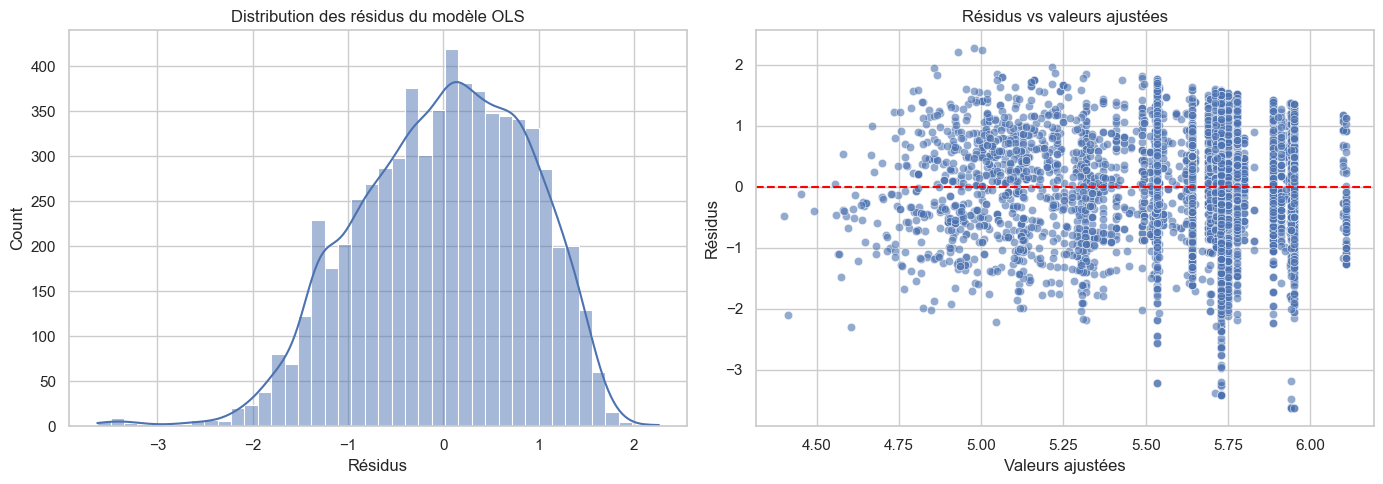

In [25]:

residuals = model.resid
fitted = model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title("Distribution des résidus du modèle OLS")
axes[0].set_xlabel("Résidus")

sns.scatterplot(x=fitted, y=residuals, alpha=0.6, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Résidus vs valeurs ajustées")
axes[1].set_xlabel("Valeurs ajustées")
axes[1].set_ylabel("Résidus")

plt.tight_layout()
if AUTO_SAVE:
    plt.savefig(OUTPUT_FIGURES / "04_regression_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()



## 23. Sauvegarde des compléments statistiques avancés


In [26]:

if AUTO_SAVE:
    ci_median_store.to_csv(OUTPUT_TABLES / "04_ci_median_price_by_store.csv", index=False, encoding="utf-8-sig")
    ci_median_category.to_csv(OUTPUT_TABLES / "04_ci_median_price_by_category.csv", index=False, encoding="utf-8-sig")
    pairwise_store_effects.to_csv(OUTPUT_TABLES / "04_pairwise_store_effect_sizes.csv", index=False, encoding="utf-8-sig")
    effect_size_summary.to_csv(OUTPUT_TABLES / "04_effect_size_summary.csv", index=False, encoding="utf-8-sig")
    power_analysis_results.to_csv(OUTPUT_TABLES / "04_power_analysis.csv", index=False, encoding="utf-8-sig")
    regression_confidence_intervals.to_csv(OUTPUT_TABLES / "04_regression_confidence_intervals.csv", index=False, encoding="utf-8-sig")
    regression_time_results.to_csv(OUTPUT_TABLES / "04_regression_with_time.csv", index=False, encoding="utf-8-sig")
    print("Compléments statistiques sauvegardés dans :", OUTPUT_TABLES)


Compléments statistiques sauvegardés dans : C:\Users\Admin\Desktop\data-analysis\outputs\tables



## 24. ANOVA avec Pingouin

Le PDF mentionne explicitement la librairie **pingouin**. Cette section ajoute une ANOVA via `pingouin`, avec taille d'effet intégrée (`np2` = partial eta-squared).

On utilise aussi Welch ANOVA, plus robuste lorsque les variances ne sont pas homogènes.


In [27]:

try:
    import pingouin as pg
    print("Pingouin version :", pg.__version__)
except ImportError as exc:
    raise ImportError("Pingouin n'est pas installé. Lance : pip install pingouin") from exc


Pingouin version : 0.6.1


In [28]:

# ANOVA classique avec pingouin : prix ~ plateforme
pg_anova_store = pg.anova(
    data=df,
    dv="price",
    between="store",
    detailed=True,
    effsize="np2"
)

# Welch ANOVA : plus adaptée si les variances sont différentes
pg_welch_store = pg.welch_anova(
    data=df,
    dv="price",
    between="store"
)

print("ANOVA Pingouin - prix par plateforme :")
display(pg_anova_store)

print("Welch ANOVA Pingouin - prix par plateforme :")
display(pg_welch_store)


ANOVA Pingouin - prix par plateforme :


,Source,SS,DF,MS,F,p_unc,np2
0,store,"35,806,415.2496",2,"17,903,207.6248",166.3688,0.0000,0.0482
1,Within,"707,761,353.6373",6577,"107,611.5788",NaN,NaN,NaN


Welch ANOVA Pingouin - prix par plateforme :


,Source,ddof1,ddof2,F,p_unc,np2
0,store,2,"2,426.7500",292.8935,0.0000,0.0482


In [29]:

# ANOVA classique avec pingouin : prix ~ catégorie
pg_anova_category = pg.anova(
    data=df,
    dv="price",
    between="category",
    detailed=True,
    effsize="np2"
)

pg_welch_category = pg.welch_anova(
    data=df,
    dv="price",
    between="category"
)

print("ANOVA Pingouin - prix par catégorie :")
display(pg_anova_category)

print("Welch ANOVA Pingouin - prix par catégorie :")
display(pg_welch_category)


ANOVA Pingouin - prix par catégorie :


,Source,SS,DF,MS,F,p_unc,np2
0,category,"12,654,119.5811",6,"2,109,019.9302",18.9661,0.0000,0.0170
1,Within,"730,913,649.3058",6573,"111,199.3990",NaN,NaN,NaN


Welch ANOVA Pingouin - prix par catégorie :


,Source,ddof1,ddof2,F,p_unc,np2
0,category,6,"1,268.1126",20.6701,0.0000,0.0170


In [30]:

# Post-hoc Games-Howell : adapté aux variances inégales
pg_gameshowell_store = pg.pairwise_gameshowell(
    data=df,
    dv="price",
    between="store"
)

pg_gameshowell_category = pg.pairwise_gameshowell(
    data=df,
    dv="price",
    between="category"
)

print("Post-hoc Games-Howell - plateformes :")
display(pg_gameshowell_store)

print("Post-hoc Games-Howell - catégories :")
display(pg_gameshowell_category.head(20))


Post-hoc Games-Howell - plateformes :


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,ebay,jumia,442.2359,237.5312,204.7047,8.5538,23.9315,"2,566.5092",0.0000,0.6210
1,ebay,sport-direct,442.2359,400.9062,41.3297,10.8602,3.8056,"1,928.7567",0.0004,0.1197
2,jumia,sport-direct,237.5312,400.9062,-163.3750,11.6043,-14.0788,"2,029.7696",0.0000,-0.5912


Post-hoc Games-Howell - catégories :


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,basketball,combat-sports,393.2698,338.4613,54.8085,18.5549,2.9539,"1,110.3341",0.0500,0.1710
1,basketball,football,393.2698,480.8958,-87.6260,19.5883,-4.4734,"1,167.1420",0.0002,-0.2562
2,basketball,gym,393.2698,330.3919,62.8779,17.6102,3.5705,972.1902,0.0068,0.2193
3,basketball,racket-sports,393.2698,464.0730,-70.8032,30.2108,-2.3436,394.1808,0.2260,-0.1974
4,basketball,unknown,393.2698,401.5498,-8.2800,15.2419,-0.5432,694.1234,0.9982,-0.0247
5,basketball,volleyball,393.2698,480.1524,-86.8826,25.8246,-3.3643,502.3249,0.0144,-0.2596
6,combat-sports,football,338.4613,480.8958,-142.4345,18.0708,-7.8820,"1,368.0863",0.0000,-0.4225
7,combat-sports,gym,338.4613,330.3919,8.0694,15.9050,0.5074,"1,261.5204",0.9988,0.0279
8,combat-sports,racket-sports,338.4613,464.0730,-125.6117,29.2497,-4.2945,354.4469,0.0004,-0.3604
9,combat-sports,unknown,338.4613,401.5498,-63.0885,13.2351,-4.7668,"1,038.1307",0.0000,-0.1890


In [31]:

if AUTO_SAVE:
    pg_anova_store.to_csv(OUTPUT_TABLES / "04_pingouin_anova_store.csv", index=False, encoding="utf-8-sig")
    pg_welch_store.to_csv(OUTPUT_TABLES / "04_pingouin_welch_store.csv", index=False, encoding="utf-8-sig")
    pg_anova_category.to_csv(OUTPUT_TABLES / "04_pingouin_anova_category.csv", index=False, encoding="utf-8-sig")
    pg_welch_category.to_csv(OUTPUT_TABLES / "04_pingouin_welch_category.csv", index=False, encoding="utf-8-sig")
    pg_gameshowell_store.to_csv(OUTPUT_TABLES / "04_pingouin_gameshowell_store.csv", index=False, encoding="utf-8-sig")
    pg_gameshowell_category.to_csv(OUTPUT_TABLES / "04_pingouin_gameshowell_category.csv", index=False, encoding="utf-8-sig")
    print("Résultats Pingouin sauvegardés dans :", OUTPUT_TABLES)


Résultats Pingouin sauvegardés dans : C:\Users\Admin\Desktop\data-analysis\outputs\tables
